In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
import gc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import time
import pickle
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from mlxtend.classifier import StackingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import gdown

# Preprocessing

## Opsi Load Data Online

In [ ]:
# load data
url_train_transaction = '1-LA_hivwi-LTmk3Il6zWc2SlWkw63lIp'
url = f'https://drive.google.com/uc?id={url_train_transaction}'
output = 'train_transaction.csv'
gdown.download(url, output, quiet=False)
train_transaction = pd.read_csv(output)

url_train_identity = '1-3IcnQe1Vk6USpMFiZcc4plMM27u2BRM'
url = f'https://drive.google.com/uc?id={url_train_identity}'
output = 'train_identity.csv'
gdown.download(url, output, quiet=False)
train_identity = pd.read_csv(output)

url_test_transaction = '1--SQCKBo6r7JKFDJU1WLVSVzj7Wmblz1'
url = f'https://drive.google.com/uc?id={url_test_transaction}'
output = 'test_transaction.csv'
gdown.download(url, output, quiet=False)
test_transaction = pd.read_csv(output)

url_test_identity = '1htmHneOewTUARR48VB5rF0k3tZIGpFcj'
url = f'https://drive.google.com/uc?id={url_test_identity}'
output = 'test_identity.csv'
gdown.download(url, output, quiet=False)
test_identity = pd.read_csv(output)

## Load Data Offline

In [ ]:
# load data
train_transaction = pd.read_csv('./dataset/train_transaction.csv')
train_identity = pd.read_csv('./dataset/train_identity.csv')
test_transaction = pd.read_csv('./dataset/test_transaction.csv')
test_identity = pd.read_csv('./dataset/test_identity.csv')

# print("data train_transaction: ", train_transaction.shape)
# print("data train_identity: ", train_identity.shape)
# print("data test_transaction: ", test_transaction.shape)
# print("data test_identity: ", test_identity.shape)

TransactionID = test_transaction['TransactionID']
# merge data
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df_test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

print("data train: ", df.shape)
print("data test: ", df_test.shape)
#ubah nama kolom
df_test.columns = df_test.columns.str.replace('^id-', 'id_', regex=True)    # replace id- to id_

#drop duplikasi data
duplicates = df.drop(columns=['TransactionID']).duplicated(keep=False)
df_duplicates = df[duplicates].drop(columns=['TransactionID'])
duplicated_index = df_duplicates.index[[1, 3, 5]]
# print(duplicated_index.tolist())
df = df.drop(duplicated_index).reset_index(drop=True)

#drop kolom
drop_column = ['id_07','id_21', 'id_22', 'id_23','id_24', 'id_25', 'id_26', 'id_27', 'TransactionID']
df.drop(drop_column, axis=1, inplace=True)
df_test.drop(drop_column, axis=1, inplace=True)

#ubah missing values
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# print(categorical_cols)
for col in categorical_cols:
    df[col] = df[col].fillna('null')
for col in categorical_cols:
    df_test[col] = df_test[col].fillna('null')

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(-999)

for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(-999)

#ubah ke numerik
encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    dff = pd.concat([df[col],df_test[col]], axis=0).sort_values().unique()
    encoder.fit(dff)
    # encoder.fit(pd.concat([train[col], test[col]], axis=0).unique())

    df[col] = encoder.transform(df[col])
    df_test[col] = encoder.transform(df_test[col])

    if df[col].max() > 32000 or df_test[col].max() > 32000:
        df[col] = df[col].astype('int32')
        df_test[col] = df_test[col].astype('int32')
    else:
        df[col] = df[col].astype('int16')
        df_test[col] = df_test[col].astype('int16')
    encoders[col] = encoder

#persiapan split data
x = df.drop('isFraud', axis=1)
y = df['isFraud']

#normalisasi data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x.astype(np.float32))
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
test_scaled = scaler.fit_transform(df_test.astype(np.float32))
test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns)

#split data
x_train, x_val, y_train, y_val = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("setelah preprocessing")
print("Train shape: ", x_train.shape)
print("Validation shape: ", x_val.shape)
print("Test shape: ", test_scaled.shape)

# store result model
result_list = []


data train:  (590540, 434)
data test:  (506691, 433)
setelah preprocessing
Train shape:  (472429, 424)
Validation shape:  (118108, 424)
Test shape:  (506691, 424)


# Modeling

In [6]:
xgb_1 = xgb.XGBClassifier( 
    random_state=42
)

# params =  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
xgb_1.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = xgb_1.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = xgb_1.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

result_list.append(
    {
        'model': 'XGBoost',
        'params': xgb_1.get_xgb_params(),
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_val, y_pred, output_dict=True)
    }
)
with open('./model/xgb_1.pkl', 'wb') as file:
    pickle.dump(xgb_1, file)

xgb_2 = xgb.XGBClassifier(
    learning_rate=0.1,  
    max_depth=9,        
    n_estimators=200,   
    random_state=42
)

# params =  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
xgb_2.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = xgb_2.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = xgb_2.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

result_list.append(
    {
        'model': 'XGBoost tuning',
        'params': xgb_2.get_xgb_params(),
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_val, y_pred, output_dict=True)
    }
)
with open('./model/xgb_2.pkl', 'wb') as file:
    pickle.dump(xgb_1, file)

lgb_1 = lgb.LGBMClassifier(random_state=42)

# Train the model
lgb_1.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_lgb = lgb_1.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_lgb = lgb_1.predict(x_val)

# Calculate AUC-ROC score
auc_roc_lgb = roc_auc_score(y_val, y_pred_prob_lgb)
print(f"AUC-ROC score: {auc_roc_lgb}")
print(classification_report(y_val, y_pred_lgb))

# Create and display the confusion matrix
cm_lgb = confusion_matrix(y_val, y_pred_lgb)
print("Confusion Matrix:")
print(cm_lgb)

# Append results to the result list
result_list.append(
    {
        'model': 'LightGBM',
        'params': lgb_1.get_params(),
        'auc_roc': auc_roc_lgb,
        'confusion_matrix': cm_lgb,
        'classification_report': classification_report(y_val, y_pred_lgb, output_dict=True)
    }
)
with open('./model/lgb_1.pkl', 'wb') as file:
    pickle.dump(lgb_1, file)

lgb_model = lgb.LGBMClassifier(
    learning_rate=0.01,  
    max_depth=12,        
    n_estimators=10000,   
    bagging_fraction=0.8,
    feature_fraction=0.4,
    boosting_type= 'gbdt',
)

# Train the model
lgb_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_lgb = lgb_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_lgb = lgb_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_lgb = roc_auc_score(y_val, y_pred_prob_lgb)
print(f"AUC-ROC score: {auc_roc_lgb}")
print(classification_report(y_val, y_pred_lgb))

# Create and display the confusion matrix
cm_lgb = confusion_matrix(y_val, y_pred_lgb)
print("Confusion Matrix:")
print(cm_lgb)

# Append results to the result list
result_list.append(
    {
        'model': 'LightGBM tuning',
        'params': lgb_model.get_params(),
        'auc_roc': auc_roc_lgb,
        'confusion_matrix': cm_lgb,
        'classification_report': classification_report(y_val, y_pred_lgb, output_dict=True)
    }
)
with open('./model/lgb_2.pkl', 'wb') as file:
    pickle.dump(lgb_model, file)

from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_logistic = logistic_model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_logistic = logistic_model.predict(x_val)

# Calculate AUC-ROC score
auc_roc_logistic = roc_auc_score(y_val, y_pred_prob_logistic)
print(f"AUC-ROC score: {auc_roc_logistic}")
print(classification_report(y_val, y_pred_logistic))

# Create and display the confusion matrix
cm_logistic = confusion_matrix(y_val, y_pred_logistic)
print("Confusion Matrix:")
print(cm_logistic)

# Append results to the result list
result_list.append(
    {
        'model': 'Logistic Regression',
        'params': logistic_model.get_params(),
        'auc_roc': auc_roc_logistic,
        'confusion_matrix': cm_logistic,
        'classification_report': classification_report(y_val, y_pred_logistic, output_dict=True)
    }
)
with open('./model/lr_1.pkl', 'wb') as file:
    pickle.dump(logistic_model, file)

AUC-ROC score: 0.9435642088535998
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.92      0.50      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.95      0.75      0.82    118108
weighted avg       0.98      0.98      0.98    118108

AUC-ROC score: 0.959633674085293
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.95      0.56      0.70      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.78      0.85    118108
weighted avg       0.98      0.98      0.98    118108

Confusion Matrix:
[[113843    132]
 [  1837   2296]]
[LightGBM] [Info] Number of positive: 16530, number of negative: 455899
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.354137 seconds.
You can set `force_row_wise=true` to remove the ov

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC-ROC score: 0.825411148621772
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.72      0.10      0.18      4133

    accuracy                           0.97    118108
   macro avg       0.84      0.55      0.58    118108
weighted avg       0.96      0.97      0.96    118108

Confusion Matrix:
[[113812    163]
 [  3713    420]]


In [ ]:
lr_2 = LogisticRegression(max_iter=10000, random_state=42)

# Train the model
lr_2.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob_logistic = lr_2.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred_logistic = lr_2.predict(x_val)

# Calculate AUC-ROC score
auc_roc_logistic = roc_auc_score(y_val, y_pred_prob_logistic)
print(f"AUC-ROC score: {auc_roc_logistic}")
print(classification_report(y_val, y_pred_logistic))

# Create and display the confusion matrix
cm_logistic = confusion_matrix(y_val, y_pred_logistic)
print("Confusion Matrix:")
print(cm_logistic)

# Append results to the result list
result_list.append(
    {
        'model': 'Logistic Regression Tuning',
        'params': lr_2.get_params(),
        'auc_roc': auc_roc_logistic,
        'confusion_matrix': cm_logistic,
        'classification_report': classification_report(y_val, y_pred_logistic, output_dict=True)
    }
)
with open('./model/lr_2.pkl', 'wb') as file:
    pickle.dump(lr_2, file)

AUC-ROC score: 0.8369804249969497
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.78      0.15      0.26      4133

    accuracy                           0.97    118108
   macro avg       0.87      0.58      0.62    118108
weighted avg       0.96      0.97      0.96    118108

Confusion Matrix:
[[113794    181]
 [  3499    634]]


In [ ]:
# coba xgb tuning
model = xgb.XGBClassifier(
    learning_rate=0.01,  
    max_depth=15,        
    n_estimators=5000,   
    subsample=0.8,
    colsample_bytree=0.8,
    # tree_method='gpu_hist',
    tree_method= 'hist',  # or 'approx'
    device='cuda'
)

# params =  {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
model.fit(x_train, y_train)

# Make predictions on the validation set
y_pred_prob = model.predict_proba(x_val)[:, 1]  # Probability of class 1 (fraud)
y_pred = model.predict(x_val)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc}")
print(classification_report(y_val, y_pred))

# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [13:21:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [13:30:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\acer\AppData\Local\Programs\Python\Python310\li

AUC-ROC score: 0.976987605631082
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.97      0.68      0.80      4133

    accuracy                           0.99    118108
   macro avg       0.98      0.84      0.90    118108
weighted avg       0.99      0.99      0.99    118108

Confusion Matrix:
[[113897     78]
 [  1338   2795]]


In [ ]:
#modeling
lr_model = LogisticRegression(random_state=42)

lgb_model = lgb.LGBMClassifier(
    learning_rate=0.01,  
    max_depth=12,        
    n_estimators=10000,   
    bagging_fraction=0.8,
    feature_fraction=0.4,
    boosting_type= 'gbdt',
)

xgb_model = xgb.XGBClassifier(
    learning_rate=0.1,  
    max_depth=9,        
    n_estimators=200,   

    # learning_rate=0.01,  
    # max_depth=15,        
    # n_estimators=5000,   
    # subsample=0.8,
    # colsample_bytree=0.8,
    # tree_method= 'hist',  # or 'approx'
    # device='cuda'
    # random_state=42
)

meta_model = MLPClassifier(hidden_layer_sizes=(50,))

stacked_model = StackingClassifier(
    classifiers=[xgb_model, lgb_model],
    meta_classifier=meta_model,
    use_probas=True,  # Gunakan probabilitas prediksi
    use_features_in_secondary=False  # Tidak gunakan fitur asli di meta-model
)

stacked_model.fit(x_train, y_train)

## Load Model

In [3]:
with open('stacked_model.pkl', 'rb') as file:
    stacked_model = pickle.load(file)

In [12]:
# Prediksi
with open('stacked_model.pkl', 'rb') as file:
    stacked_model = pickle.load(file)
    
y_pred_prob = stacked_model.predict_proba(x_val)[:, 1] 
y_pred = stacked_model.predict(x_val)
auc_roc_stack = roc_auc_score(y_val, y_pred_prob)

print(f"AUC-ROC score: {auc_roc_stack}")
print(classification_report(y_val, y_pred))
# Create and display the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)

# result_list.append(
#     {
#         'model': 'Stack ensemble',
#         'params': stacked_model.get_params(),
#         'auc_roc': auc_roc_stack,
#         'confusion_matrix': cm,
#         'classification_report': classification_report(y_val, y_pred, output_dict=True)
#     }
# )

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
AUC-ROC score: 0.9667373326688018
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.88      0.70      0.78      4133

    accuracy                           0.99    118108
   macro avg       0.94      0.85      0.89    118108
weighted avg       0.99      0.99      0.99    118108

Confusion Matrix:
[[113596    379]
 [  1250   2883]]


In [10]:
df_results = pd.DataFrame(result_list)
df_results.to_csv('2025 05 31 results.csv', index=False)
df_results

,model,params,auc_roc,confusion_matrix,classification_report
0,XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.943564,"[[113787, 188], [2049, 2084]]","{'0': {'precision': 0.9823111985911116, 'recal..."
1,XGBoost tuning,"{'objective': 'binary:logistic', 'base_score':...",0.959634,"[[113843, 132], [1837, 2296]]","{'0': {'precision': 0.9841199861687413, 'recal..."
2,LightGBM,"{'boosting_type': 'gbdt', 'class_weight': None...",0.928296,"[[113748, 227], [2370, 1763]]","{'0': {'precision': 0.9795897276907973, 'recal..."
3,LightGBM tuning,"{'boosting_type': 'gbdt', 'class_weight': None...",0.966512,"[[113863, 112], [1676, 2457]]","{'0': {'precision': 0.9854940755935225, 'recal..."
4,Logistic Regression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.825411,"[[113812, 163], [3713, 420]]","{'0': {'precision': 0.9684067219740481, 'recal..."
5,Stack ensemble,"{'average_probas': False, 'classifiers': [XGBC...",0.966737,"[[113596, 379], [1250, 2883]]","{'0': {'precision': 0.9891158594988071, 'recal..."


In [11]:
df_results[['model', 'auc_roc']].sort_values(by='auc_roc', ascending=False)

,model,auc_roc
5,Stack ensemble,0.966737
3,LightGBM tuning,0.966512
1,XGBoost tuning,0.959634
0,XGBoost,0.943564
2,LightGBM,0.928296
4,Logistic Regression,0.825411


In [19]:
df_results = pd.read_csv('2025 05 31 results.csv')
df_results

,model,params,auc_roc,confusion_matrix,classification_report
0,XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.943564,[[113787 188]\n [ 2049 2084]],"{'0': {'precision': 0.9823111985911116, 'recal..."
1,XGBoost tuning,"{'objective': 'binary:logistic', 'base_score':...",0.959634,[[113843 132]\n [ 1837 2296]],"{'0': {'precision': 0.9841199861687413, 'recal..."
2,LightGBM,"{'boosting_type': 'gbdt', 'class_weight': None...",0.928296,[[113748 227]\n [ 2370 1763]],"{'0': {'precision': 0.9795897276907973, 'recal..."
3,LightGBM tuning,"{'boosting_type': 'gbdt', 'class_weight': None...",0.966512,[[113863 112]\n [ 1676 2457]],"{'0': {'precision': 0.9854940755935225, 'recal..."
4,Logistic Regression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.825411,[[113812 163]\n [ 3713 420]],"{'0': {'precision': 0.9684067219740481, 'recal..."
5,Stack ensemble,"{'average_probas': False, 'classifiers': [XGBC...",0.966737,[[113596 379]\n [ 1250 2883]],"{'0': {'precision': 0.9891158594988071, 'recal..."


In [ ]:
new_result = pd.DataFrame(result_list)
df_results = pd.concat([df_results, new_result], ignore_index=True)
df_results[['model', 'auc_roc']].sort_values(by='auc_roc', ascending=False)

,model,auc_roc
5,Stack ensemble,0.966737
3,LightGBM tuning,0.966512
1,XGBoost tuning,0.959634
0,XGBoost,0.943564
2,LightGBM,0.928296
6,Logistic Regression Tuning,0.836980
4,Logistic Regression,0.825411


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

In [ ]:
df_results

In [11]:
y_val.value_counts()

isFraud
0    113975
1      4133
Name: count, dtype: int64

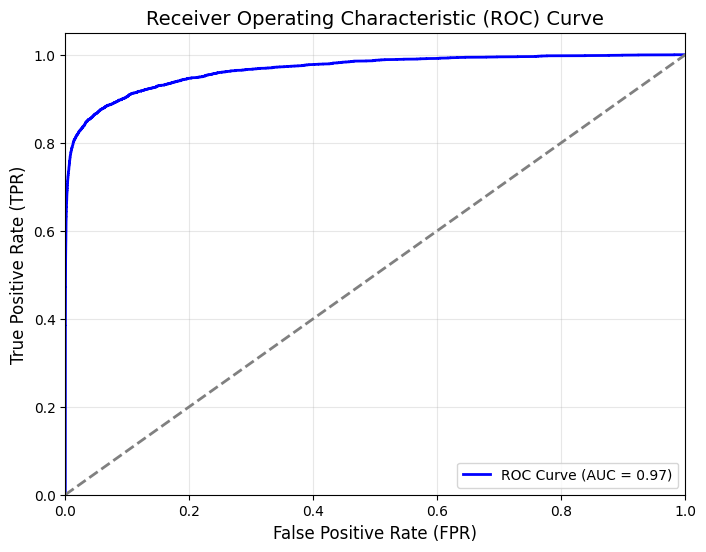

In [16]:
# Hitung False Positive Rate (FPR) dan True Positive Rate (TPR)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)

# Plot Grafik ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, 
         label=f'ROC Curve (AUC = {auc_roc_stack:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Garis acak (AUC = 0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.88      0.70      0.78      4133

    accuracy                           0.99    118108
   macro avg       0.94      0.85      0.89    118108
weighted avg       0.99      0.99      0.99    118108



<Figure size 800x600 with 0 Axes>

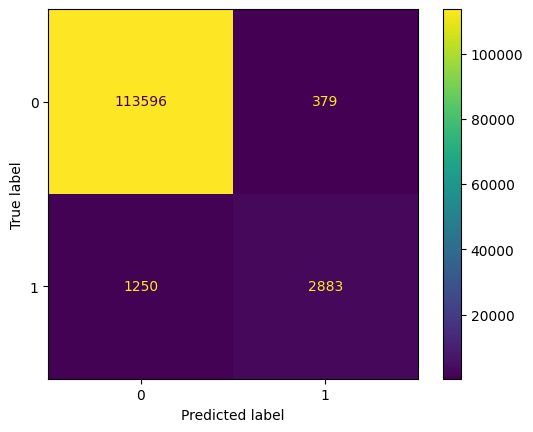

In [ ]:
plt.figure(figsize=(8, 6))
y_pred_swapped = np.where(y_pred == 0, 1, 0)
y_pred_prob_swapped = 1 - y_pred_prob
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

<Figure size 800x600 with 0 Axes>

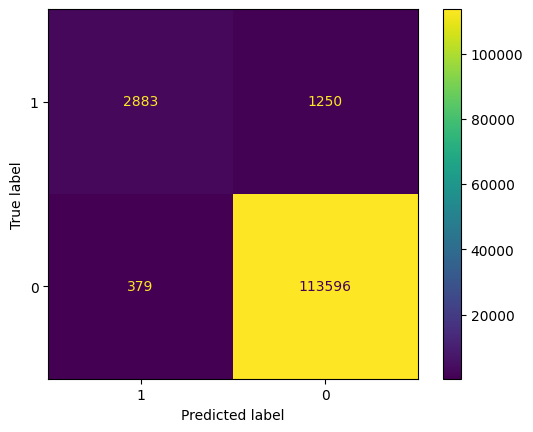

In [17]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 0])
disp.plot()
plt.show()

<Figure size 800x600 with 0 Axes>

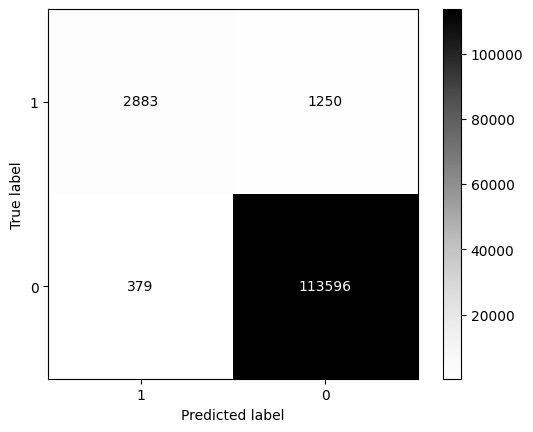

In [12]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 0])
disp.plot(cmap='Greys')  # Use monochrome colormap
plt.show()

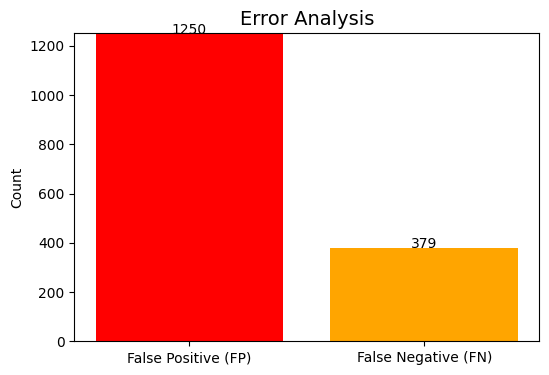

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Analisis Error: False Positive (FP) dan False Negative (FN)
error_types = {
    'False Positive (FP)': cm[0, 1],  # Actual 0, Predicted 1
    'False Negative (FN)': cm[1, 0]   # Actual 1, Predicted 0
}

# Plot Error Analysis
plt.figure(figsize=(6, 4))
plt.bar(error_types.keys(), error_types.values(), color=['red', 'orange'])
plt.title('Error Analysis', fontsize=14)
plt.ylabel('Count')
plt.ylim(0, max(error_types.values()) + 1)
for i, v in enumerate(error_types.values()):
    plt.text(i, v + 0.1, str(v), ha='center')
plt.show()

## Save Model

In [ ]:
with open('stacked_model.pkl', 'wb') as file:
    pickle.dump(stacked_model, file)

In [ ]:
meta_model = MLPClassifier(hidden_layer_sizes=(50,))
stacked_model = StackingClassifier(
    classifiers=[lgb_model, xgb_model],
    meta_classifier=meta_model,
    use_probas=True,  # Gunakan probabilitas prediksi
    use_features_in_secondary=False,
)

stacked_model.fit(x_train, y_train)

# Prediksi
y_pred_prob = stacked_model.predict_proba(x_val)[:, 1] 
# y_pred = stacked_model.predict(x_val)
auc_roc_stack = roc_auc_score(y_val, y_pred_prob)
print(f"AUC-ROC score: {auc_roc_stack}")

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.331243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38347
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 423
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM]

# Pake CV

In [ ]:
# Meta-model
meta_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)

# Stacked model
stacked_model = StackingClassifier(
    classifiers=[lgb_model, xgb_model],
    meta_classifier=meta_model,
    use_probas=True,
    use_features_in_secondary=False
)

# Gunakan ROC AUC sebagai scoring
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Cross-validation
scores = cross_val_score(
    estimator=stacked_model,
    X=x_train,
    y=y_train,
    cv=5,
    scoring=auc_scorer
)

print("Cross-validated AUC-ROC scores:", scores)
print("Mean AUC-ROC:", scores.mean())

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 13224, number of negative: 364721
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.285510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 38304
[LightGBM] [Info] Number of data points in the train set: 377945, number of used features: 423
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317099
[LightGBM]

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 

# Simulasi

In [3]:
with open('stacked_model.pkl', 'rb') as file:
    stacked_model = pickle.load(file)

In [4]:
list_simulation = []

In [11]:
# import time

# Simulate testing each data point in test_scaled
batching = [1,100,1000]

for batch_size in batching:
    if batch_size == 1:
        test_ = test_scaled[:100]
    elif batch_size == 100:
        test_ = test_scaled[:1000]
    else:
        test_ = test_scaled[:10000]
    
    latency_times = []
    num_batches = len(test_scaled) // batch_size
    for batch_idx in range(batch_size):
        start_time = time.time()
        batch_data = test_.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
        result_fraud = stacked_model.predict(batch_data)  
        end_time = time.time()  
        latency_times.append(end_time - start_time)

    average_latency = sum(latency_times) / len(latency_times)
    print(f"Batch size {batch_size} average latency: {average_latency:.2f} detik")
    print(f"Batch size {batch_size} total latency: {end_time - start_time:.2f} detik")
    print(f"Batch size {batch_size} maximum latency: {max(latency_times):.2f} detik")
    print(f"Batch size {batch_size} minimum latency: {min(latency_times):.2f} detik")
    list_simulation.append({
        'model': 'Stack',
        'batch_size': batch_size,
        'average_latency': sum(latency_times) / len(latency_times),
        'total_latency': sum(latency_times),
        'max_latency': max(latency_times),
        'min_latency': min(latency_times)
    })

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch size 1 average latency: 0.12 detik
Batch size 1 total latency: 0.12 detik
Batch size 1 maximum latency: 0.12 detik
Batch size 1 minimum latency: 0.12 detik
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_frac

ValueError: Input data must be 2 dimensional and non empty.

In [5]:
import time

# Simulate testing each data point in test_scaled
latency_times = []
len_test_scaled = len(test_scaled[:1000])  # Limit to first 1000 rows for testing
for i in range(len_test_scaled):
    start_time = time.time()
    result_fraud = stacked_model.predict(test_scaled.iloc[i:i+1])  # Predict one row at a time
    if result_fraud == 1:
        print(f"Fraud detected at index {i}")
    end_time = time.time()
    latency_times.append(end_time - start_time)

# Calculate and display latency statistics
average_latency = sum(latency_times) / len(latency_times)

print(f"Model {stacked_model.__class__.__name__}")
print(f"Rata2 latency per 1 data: {average_latency:.2f} detik")
print(f"Total latency untuk {len_test_scaled} per 1 data: {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {len_test_scaled} per 1 data: {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {len_test_scaled} per 1 data: {min(latency_times):.2f} detik")

list_simulation.append({
    'model': 'Stack',
    'batch_size': 1,
    'average_latency': average_latency,
    'total_latency': sum(latency_times),
    'max_latency': max(latency_times),
    'min_latency': min(latency_times)
})

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fractio

In [6]:
batch_size = 100
num_batches = len(test_scaled) // batch_size
latency_times = []

for batch_idx in range(num_batches):
    start_time = time.time()
    batch_data = test_scaled.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
    result_fraud = stacked_model.predict(batch_data)  # Predict the batch
    end_time = time.time()
    
    # Calculate latency for the batch
    latency_times.append(end_time - start_time)
    print(f"Batch {batch_idx + 1}/{num_batches} processed. Latency: {latency_times[-1]:.6f} seconds")

# Calculate and display overall latency statistics
average_latency = sum(latency_times) / len(latency_times)
print(f"Rata2 latency per batch (per {batch_size} data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per {batch_size} data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per {batch_size} data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per {batch_size} data): {min(latency_times):.2f} detik")
print(f"Jumlah batch: {num_batches}")

list_simulation.append({
    'model': 'Stack',
    'batch_size': batch_size,
    'average_latency': average_latency,
    'total_latency': sum(latency_times),
    'max_latency': max(latency_times),
    'min_latency': min(latency_times)
})

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 1/5066 processed. Latency: 0.137499 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 2/5066 processed. Latency: 0.147711 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 3/5066 processed. Latency: 0.131539 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[Li

In [7]:
batch_size = 1000
num_batches = len(test_scaled) // batch_size
latency_times = []

for batch_idx in range(num_batches):
    start_time = time.time()
    batch_data = test_scaled.iloc[batch_idx * batch_size:(batch_idx + 1) * batch_size]
    result_fraud = stacked_model.predict(batch_data)  # Predict the batch
    end_time = time.time()
    
    # Calculate latency for the batch
    latency_times.append(end_time - start_time)
    print(f"Batch {batch_idx + 1}/{num_batches} processed. Latency: {latency_times[-1]:.6f} seconds")

# Calculate and display overall latency statistics
average_latency = sum(latency_times) / len(latency_times)
print(f"Rata2 latency per batch (per {batch_size} data): {average_latency:.2f} detik")
print(f"Total latency untuk {num_batches} batch (per {batch_size} data): {sum(latency_times):.2f} detik")
print(f"Maksimum latency untuk {num_batches} batch (per {batch_size} data): {max(latency_times):.2f} detik")
print(f"Minimum latency untuk {num_batches} batch (per {batch_size} data): {min(latency_times):.2f} detik")
print(f"Jumlah batch: {num_batches}")

list_simulation.append({
    'model': 'Stack',
    'batch_size': batch_size,
    'average_latency': average_latency,
    'total_latency': sum(latency_times),
    'max_latency': max(latency_times),
    'min_latency': min(latency_times)
})

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 1/506 processed. Latency: 0.313103 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 2/506 processed. Latency: 0.313287 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Batch 3/506 processed. Latency: 0.308811 seconds
[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[Light

In [8]:
df_simulation = pd.DataFrame(list_simulation)
df_simulation.to_csv('2025 05 31 simulation.csv', index=False)
df_simulation

,model,batch_size,average_latency,total_latency,max_latency,min_latency
0,Stack,1,0.150092,150.091944,0.569286,0.121516
1,Stack,100,0.152359,771.852499,0.705504,0.122520
2,Stack,1000,0.308859,156.282711,0.875814,0.281601


In [9]:
test_scaled.shape

(506691, 424)

# Submit Kaggle

In [4]:
isFraud = stacked_model.predict(test_scaled)

# TransactionID = test_transaction['TransactionID']
test_result = pd.DataFrame({'TransactionID': TransactionID, 'isFraud': isFraud})
test_result.to_csv('2025 05 31 submission.csv', index=False)
test_result['isFraud'].value_counts()

[LightGBM] [Warning] feature_fraction is set=0.4, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


isFraud
0    498300
1      8391
Name: count, dtype: int64

In [ ]:
test_result

,TransactionID,isFraud
0,3663549,0
1,3663550,0
2,3663551,0
3,3663552,0
4,3663553,0
...,...,...
506686,4170235,0
506687,4170236,0
506688,4170237,0
506689,4170238,0


Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
    data = self._ssock.recv(4096)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\asyncio\selector_events.py", line 115, in _read_from_self
 